# CRISP-DM Phase 3: Data Preparation (Hospital Regression Dataset)

In this phase, we tackle extreme dataset skew and complex string matrices. Our core objectives:
1. **Mathematical Junk Scrubbing**: Handle repeating header rows.
2. **NLP Text Vectorization**: The diseases are typed as complex comma-separated paragraphs. We will use Natural Language Processing to extract keyword importance.
3. **Logarithmic Scaling**: We have extreme 960g dose outliers. A log transformation will compress these mathematical extremes safely.
4. **Export Engine**: Generate final ML-ready `.csv` files.

**Path resolution:** Same as the Data Understanding notebook — run from the repo root or from `regression_hospital_data _set/` so `Hopsital Dataset.csv` resolves via `Path`.

**Five-supervisor framing:** This notebook supports structured review by **two data-analysis lenses** (profiling + quality rules), **two ML lenses** (leakage/splits + feature design), and **MLOps** (reproducible artifacts). See **§1b** (visuals, missing, IQR report) and **§7** (sign-off table).


In [15]:
import json
from IPython.display import display
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')


## 1. Load & Clean Raw Data
**Why are we doing this?** The raw CSV from the hospital database injected the column headers over and over again randomly as "rows". If we don't clear these string combinations out instantly, Python treats the numbers as text and crashes.

In [16]:
TARGET_COL = 'Duration (days)'
RANDOM_STATE = 42

candidate_roots = [Path.cwd(), Path.cwd() / 'regression_hospital_data _set']
base_dir = next((r for r in candidate_roots if (r / 'Hopsital Dataset.csv').exists()), None)
if base_dir is None:
    raise FileNotFoundError('Hopsital Dataset.csv not found; run from repo root or regression_hospital_data _set/')
DATA_FILE = base_dir / 'Hopsital Dataset.csv'

# Immutable raw load; working table is df_work (governance aligned with DU notebook).
df_raw = pd.read_csv(DATA_FILE, low_memory=False)

checks = [
    (df_raw['Age'].astype(str).str.strip() == 'Age'),
    (df_raw[TARGET_COL].astype(str).str.strip() == TARGET_COL),
    (df_raw['Gender'].astype(str).str.strip() == 'Gender'),
]
mask = pd.Series(False, index=df_raw.index)
for c in checks:
    mask = mask | c
N_AFTER_JUNK = int((~mask).sum())
df_work = df_raw.loc[~mask].copy()

df_work['Age_num'] = pd.to_numeric(df_work['Age'], errors='coerce')
df_work['Dosage_num'] = pd.to_numeric(df_work['Dosage (gram)'], errors='coerce')
df_work['Duration_num'] = pd.to_numeric(df_work[TARGET_COL], errors='coerce')

df_work.dropna(subset=['Age_num', 'Dosage_num', 'Duration_num'], inplace=True)
N_AFTER_NUMERIC = len(df_work)

dup_n = int(df_work.duplicated().sum())
df_work = df_work.drop_duplicates(keep='first', ignore_index=True)
print(f"Exact duplicate rows removed: {dup_n} (keep='first'). Rows after dedup: {len(df_work)}")
print(f"Pipeline: raw {len(df_raw)} → post-junk {N_AFTER_JUNK} → complete numerics {N_AFTER_NUMERIC} → dedup {len(df_work)}")


Exact duplicate rows removed: 7 (keep='first'). Rows after dedup: 824
Pipeline: raw 833 → post-junk 832 → complete numerics 831 → dedup 824


## 1b. Data quality, outliers, and pre-split visuals

**Purpose:** Before splitting, document **missingness**, **exact duplicate** handling (already applied in §1), and **IQR-based outlier counts** for core numerics. Plots support five-supervisor review (Data Analysis / ML / MLOps).

**Policy:** Rows with missing **Age / Dosage / Duration** were dropped in §1 (complete-case for those fields). Remaining NaNs in other columns are handled per column (e.g. TF-IDF 

illna(''), categoricals → 'Missing'). **IQR flags** are **report-only** here; winsorization or domain caps belong to a governed change in the modeling notebook if required.


Columns with missing values (fraction of rows):


,fraction_missing
Indication,0.001214


IQR-flagged row counts (report only): {'Age_num': 0, 'Dosage_num': 31, 'Duration_num': 19}


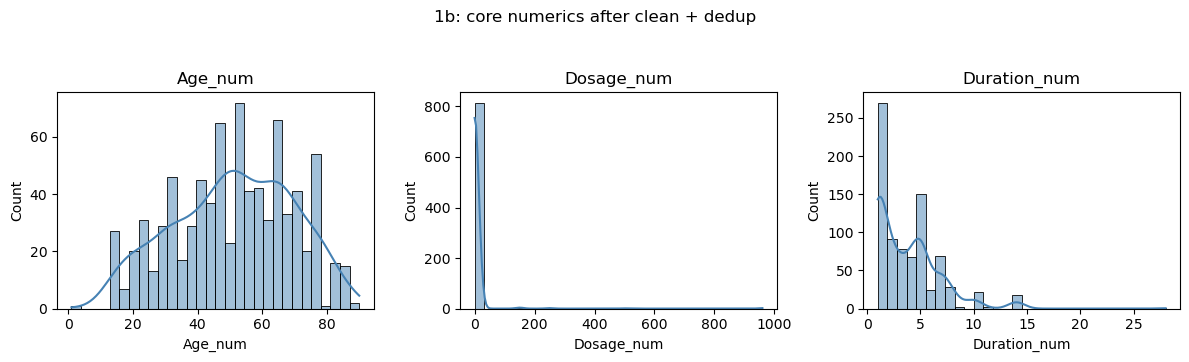

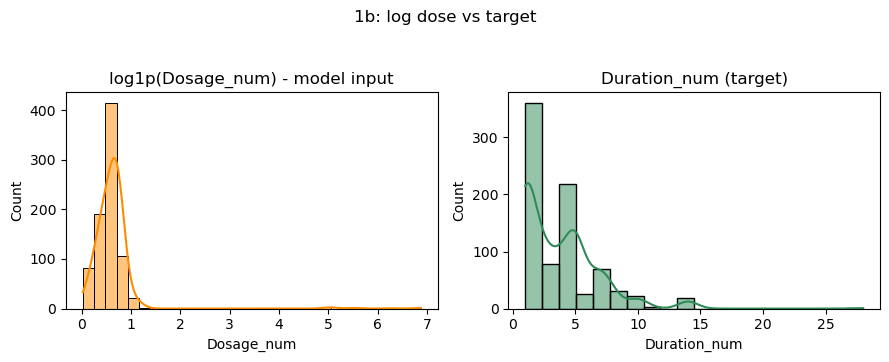

In [17]:
# Uses display from imports cell

# --- Missingness on modeling cohort (after dedup) ---
miss_frac = df_work.isna().mean().sort_values(ascending=False)
miss_nonzero = miss_frac[miss_frac > 0]
if len(miss_nonzero):
    print('Columns with missing values (fraction of rows):')
    display(miss_nonzero.to_frame('fraction_missing'))
else:
    print('No NaN values remain in df_work (all columns).')

PREP_MISSING_TOP = miss_frac.head(15).to_dict()

# --- IQR outlier counts (Tukey fences; exploratory, not auto-dropped) ---

def _iqr_outlier_n(s: pd.Series) -> int:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    spread = 1.5 * iqr
    lo, hi = q1 - spread, q3 + spread
    return int(((s < lo) | (s > hi)).sum())


PREP_IQR_OUTLIERS = {
    'Age_num': _iqr_outlier_n(df_work['Age_num']),
    'Dosage_num': _iqr_outlier_n(df_work['Dosage_num']),
    'Duration_num': _iqr_outlier_n(df_work['Duration_num']),
}
print('IQR-flagged row counts (report only):', PREP_IQR_OUTLIERS)

# --- Distributions (feature engineering context: skew / heavy tails) ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, col in zip(axes, ['Age_num', 'Dosage_num', 'Duration_num']):
    sns.histplot(df_work[col], bins=30, ax=ax, kde=True, color='steelblue')
    ax.set_title(col)
plt.suptitle('1b: core numerics after clean + dedup', y=1.05)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
sns.histplot(np.log1p(df_work['Dosage_num']), bins=30, ax=axes[0], kde=True, color='darkorange')
axes[0].set_title('log1p(Dosage_num) - model input')
sns.histplot(df_work['Duration_num'], bins=20, ax=axes[1], kde=True, color='seagreen')
axes[1].set_title('Duration_num (target)')
plt.suptitle('1b: log dose vs target', y=1.05)
plt.tight_layout()
plt.show()


## 2. Train / Test Split
**Why are we doing this FIRST?** We must split the dataset into 80% Training and 20% Testing **BEFORE** we run our NLP algorithms. If we do it after, the model "memorizes" vocabulary from the test set, creating Data Leakage.

In [18]:
drop_x = [
    'Duration_num',
    TARGET_COL,
    'Age',
    'Dosage (gram)',
    'Date of Data Entry',  # avoid implicit calendar features; time-based splits documented in metadata
]
X = df_work.drop(columns=[c for c in drop_x if c in df_work.columns], errors='ignore')
y = df_work['Duration_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Training set: {X_train.shape}")


Training set: (659, 8)


## 3. NLP text vectorization (TF–IDF)

### What is NLP here?

**Natural Language Processing (NLP)** is a set of methods to turn **unstructured text** (diagnoses, drug phrases, indications) into **numeric inputs** a regression model can use. We do not need deep learning for this baseline: a **bag-of-words** pipeline is enough.

- **Tokenization:** split text into words (after lowercasing); punctuation is stripped by the vectorizer.
- **TF (term frequency):** how often a token appears in *this* document.
- **IDF (inverse document frequency):** down-weights tokens that appear in almost every document (less discriminative).
- **TF–IDF** combines both so each cell gets a score per token: important when a word is **specific** to a few patients.

### How we apply it in this notebook

We use `sklearn.feature_extraction.text.TfidfVectorizer` on **`Diagnosis`**, **`Name of Drug`**, and **`Indication`**. Each column gets up to **`max_features=15`** tokens plus English **stop-word** removal to limit noise and width. The vectorizer is **`fit` on `X_train` only** and **`transform`** on **`X_test`** — this prevents vocabulary leakage from the test set.

**Why not one-hot on full diagnosis strings?** Thousands of unique multi-word phrases would explode dimensionality and sparsity; TF–IDF compresses signal into a small, interpretable slice of tokens.

**Refinements for later experiments:** change `max_features`, add `min_df`, use `ngram_range=(1, 2)` for two-word phrases, or try `HashingVectorizer` for very large text — record any change in `metadata.json`.


In [19]:
text_cols = ['Diagnosis', 'Name of Drug', 'Indication']
tfidf_features_train = []
tfidf_features_test = []
feature_names_out = []

for col in text_cols:
    # Initialize NLP Vectorizer targeting the top 15 words per column
    vectorizer = TfidfVectorizer(max_features=15, stop_words='english')
    
    # Fit strictly on train data to prevent leakage
    train_mat = vectorizer.fit_transform(X_train[col].fillna(''))
    test_mat = vectorizer.transform(X_test[col].fillna(''))
    
    tfidf_features_train.append(pd.DataFrame(train_mat.toarray(), index=X_train.index))
    tfidf_features_test.append(pd.DataFrame(test_mat.toarray(), index=X_test.index))
    
    # Track column names
    feature_names_out.extend([f"{col}_{word}" for word in vectorizer.get_feature_names_out()])

# Combine all NLP features
df_tfidf_train = pd.concat(tfidf_features_train, axis=1)
df_tfidf_test = pd.concat(tfidf_features_test, axis=1)

df_tfidf_train.columns = feature_names_out
df_tfidf_test.columns = feature_names_out
print("NLP Processing Complete. Top words extracted!")
display(df_tfidf_train.head(3))

NLP Processing Complete. Top words extracted!


,Diagnosis_acute,Diagnosis_ccf,Diagnosis_chest,Diagnosis_ckd,Diagnosis_col,Diagnosis_copd,Diagnosis_dm,Diagnosis_hypertension,Diagnosis_ihd,Diagnosis_infection,...,Indication_dm,Indication_fever,Indication_infection,Indication_koch,Indication_left,Indication_lung,Indication_pneumonia,Indication_prevention,Indication_type,Indication_uti
239,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,...,0.000000,0.0,0.668912,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
708,0.0,0.0,0.490256,0.726497,0.000000,0.000000,0.000000,0.0,0.000000,0.481509,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
760,0.0,0.0,0.000000,0.000000,0.400146,0.478641,0.408089,0.0,0.487803,0.000000,...,0.707107,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.707107,0.0


## 4. Addressing Skew: Log Transformations
**Why `np.log1p`?** Our `Dosage` numbers mostly hover around 1-5g, but some spike to 960g! If we feed 960g to a Regression algorithm, the model line will completely break. A Logarithmic transformation cleanly compresses massive numbers into a smooth curve without deleting the data.
**Why `MinMaxScaler`?** We use this to scale `Age` cleanly between 0 and 1.

In [20]:
# 1. Log Transform Dosage
X_train_log = np.log1p(X_train['Dosage_num'])
X_test_log = np.log1p(X_test['Dosage_num'])

# 2. MinMax Scale Age
scaler = MinMaxScaler()
X_train_age = scaler.fit_transform(X_train[['Age_num']])
X_test_age = scaler.transform(X_test[['Age_num']])

# Reconstruct numeric dataframe
df_num_train = pd.DataFrame({'Log_Dosage': X_train_log, 'Scaled_Age': X_train_age.flatten()}, index=X_train.index)
df_num_test = pd.DataFrame({'Log_Dosage': X_test_log, 'Scaled_Age': X_test_age.flatten()}, index=X_test.index)
print("Numerical Skew mathematically stabilized.")

Numerical Skew mathematically stabilized.


## 5. Standard Categorical Processing
**Why One-Hot?** For simple text columns with low limits (`Gender`, `Route`, `Frequency`), standard binary flagging (0 or 1) is flawless.

In [21]:
cat_cols = ['Gender', 'Route', 'Frequency']

# handle_unknown='ignore' protects us if the test set has a category the train set missed
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit on Train, transform both
cat_train_mat = ohe.fit_transform(X_train[cat_cols].fillna('Missing'))
cat_test_mat = ohe.transform(X_test[cat_cols].fillna('Missing'))

cat_feature_names = ohe.get_feature_names_out(cat_cols)

df_cat_train = pd.DataFrame(cat_train_mat, columns=cat_feature_names, index=X_train.index)
df_cat_test = pd.DataFrame(cat_test_mat, columns=cat_feature_names, index=X_test.index)

## 6. Matrix Alignment and Export
We glue our NLP matrix, Log columns, and One-hot matrices together into the final perfect dataset.

In [22]:
FINAL_X_train = pd.concat([df_num_train, df_cat_train, df_tfidf_train], axis=1)
FINAL_X_test = pd.concat([df_num_test, df_cat_test, df_tfidf_test], axis=1)

print(f"Final Train Data Shape: {FINAL_X_train.shape}")

out_dir = base_dir / 'data' / 'processed' / 'hospital'
out_dir.mkdir(parents=True, exist_ok=True)

FINAL_X_train.to_csv(out_dir / 'X_train.csv', index=False)
FINAL_X_test.to_csv(out_dir / 'X_test.csv', index=False)
y_train.to_csv(out_dir / 'y_train.csv', index=False)
y_test.to_csv(out_dir / 'y_test.csv', index=False)

meta = {
    "notebook": "02b_DataPreparation_Hospital.ipynb",
    "random_state": RANDOM_STATE,
    "train_test_split": "random_80_20",
    "tfidf_max_features_per_text_col": 15,
    "row_counts": {
        "raw": len(df_raw),
        "after_junk_filter": N_AFTER_JUNK,
        "after_numeric_complete": N_AFTER_NUMERIC,
        "after_dedup": int(len(df_work)),
        "train_rows": int(len(FINAL_X_train)),
        "test_rows": int(len(FINAL_X_test)),
    },
    "features_dropped_from_X": [c for c in drop_x if c in df_work.columns],
    "X_train_columns": list(FINAL_X_train.columns),
    "categorical_one_hot": cat_cols,
    "text_tfidf_sources": text_cols,
    "prep_quality": {
        "iqr_outlier_counts_report_only": PREP_IQR_OUTLIERS,
        "missing_fraction_by_column_top15": PREP_MISSING_TOP,
    },
    "notes": "Date of Data Entry excluded from X; for leakage-safe temporal experiments use a date-based split and document in metadata.",
}
(out_dir / 'metadata.json').write_text(json.dumps(meta, indent=2), encoding='utf-8')
print(f"Exported matrices and metadata.json to: {out_dir.resolve()}")


Final Train Data Shape: (659, 53)
Exported matrices and metadata.json to: C:\Users\rahma\Desktop\machine learning project\regression_hospital_data _set\data\processed\hospital


## 7. Five-supervisor preparation sign-off (roles)

Use this table in project reviews. Each role signs off on risks they own; refinements loop back into this notebook or `metadata.json`.

| Role | Focus | Questions | Status (fill) |
|------|--------|-----------|---------------|
| **Supervisor 1 — Data analysis (profiling)** | Distributions, missingness, duplicates | Do counts match `metadata.row_counts`? Are IQR flags plausible for admin data? | |
| **Supervisor 2 — Data analysis (quality rules)** | Drop vs impute, dedup policy | Is `drop_duplicates(keep='first')` valid for the source system? Should any outlier be capped with clinical input? | |
| **Supervisor 3 — ML (leakage & splits)** | Split before NLP/scaling; target handling | Is random 80/20 acceptable, or is a **time-based** split required using entry date? | |
| **Supervisor 4 — ML (features)** | Scaling, NLP width, linear model assumptions | Is `log1p` dose + `MinMax` age enough? Consider `StandardScaler` for some linear models; tune TF–IDF `max_features`. | |
| **Supervisor 5 — MLOps (reproducibility)** | Paths, seeds, artifacts | Are `RANDOM_STATE`, `X_*` / `y_*` CSVs, and `metadata.json` version-controlled and runnable from CI? | |
